In [2]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.optimize import differential_evolution
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import GridSearchCV
from scipy import optimize

<Axes: xlabel='Time', ylabel='vals'>

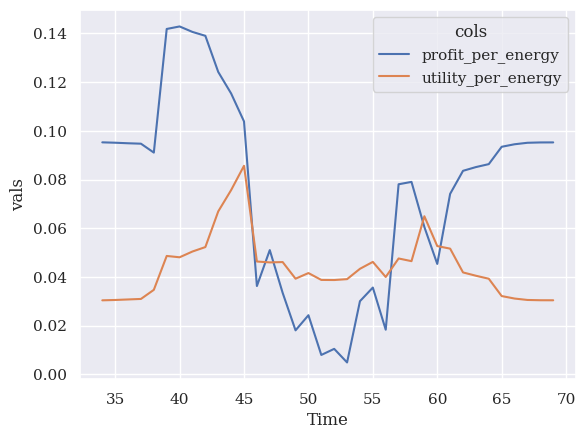

In [36]:
data = pd.read_excel("./data/input_data_70_pv.xlsx")
data.set_index(["Time","ID"],inplace=True)
data["deposited_money"]=data["demand"]*data["bid_price_buyers"]

# define price function
def price_function(X, Y, K_upper, K_lower, theta, B):
    ratio = Y/X
    return K_upper - (K_upper - K_lower) / (1 + np.exp(-B * (ratio - theta)))

    
def calculate_returns(data,midpoint,steepness):
    c = data.copy()
    out = pd.DataFrame(columns=["Time","k_lower","k_upper","sum_energy","sum_money","price","total_affordable_energy","sum_sold_energy","total_demand"])
    for i in data.index.get_level_values(0).unique():
        slice = c.xs(i)
        k_lower= slice["sell_price"].mean()
        k_upper = slice["buy_price"].mean()
        sum_energy = slice["surplus"].sum()
        sum_money = slice["deposited_money"].sum()
        total_demand = slice["demand"].sum()
        price = price_function(sum_money,sum_energy,k_upper,k_lower,midpoint,steepness)
        total_affordable_energy= sum_money/price
        sum_sold_energy = min(total_affordable_energy,sum_energy)
        out.loc[i]= {"Time":i,"k_lower":k_lower,"k_upper":k_upper,"sum_energy":sum_energy,"sum_money":sum_money,"price":price,"total_affordable_energy":total_affordable_energy,"sum_sold_energy":sum_sold_energy,"total_demand":total_demand}
        for j,row in slice.iterrows():
            if row.demand > 0:
                received_energy = sum_sold_energy * (row["deposited_money"]/sum_money)
                c.loc[(i,j),"received_energy"] = received_energy
                cost_received_energy = received_energy*price
                c.loc[(i,j),"cost_received_energy"] = cost_received_energy
                remaining_demand = max(row["demand"]-received_energy,0)
                c.loc[(i,j),"remaining_demand"] = remaining_demand
                excess_received_energy = max(received_energy - row["demand"],0)
                c.loc[(i,j),"excess_received_energy"] = excess_received_energy
                utility_per_energy = row.buy_price-price
                cost_per_excess_energy = price- row["sell_price"]
                c.loc[(i,j),"cost_per_excess_energy"] = cost_per_excess_energy
                utility = utility_per_energy*(received_energy-excess_received_energy) - excess_received_energy*cost_per_excess_energy
                utility_per_energy = None if received_energy ==0 else utility/received_energy
                c.loc[(i,j),"utility"] = utility
                c.loc[(i,j),"utility_per_energy"] = utility_per_energy
            else:
                sold_energy = sum_sold_energy*(row.surplus/sum_energy)
                c.loc[(i,j),"sold_energy"] = sold_energy
                received_money = sold_energy*price
                c.loc[(i,j),"received_money"] = received_money
                unsold_energy = max(row.surplus - sold_energy,0)
                c.loc[(i,j),"unsold_energy"] = unsold_energy
                profit_per_energy = price - row["sell_price"]
                c.loc[(i,j),"profit_per_energy"] = profit_per_energy
                profit = sold_energy*profit_per_energy
                c.loc[(i,j),"profit"] = profit 

    return out,c
        

#df = calculate_returns(data,1,1)[["sum_energy","Time","sum_money","total_affordable_energy","sum_sold_energy"]]
#df = df.melt("Time",var_name="cols",value_name="vals")
#sns.lineplot(df,x="Time",y="vals",hue="cols")
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
out, df = calculate_returns(data,optimal_params["alpha = 0.5 scenario_high:"]["midpoint"],optimal_params["alpha = 0.5 scenario_high:"]["steepness"])
df1 = df.reset_index()[["Time","profit_per_energy","utility_per_energy","profit","utility"]].groupby(by="Time").agg({"profit_per_energy":"mean","utility_per_energy":"mean"}).reset_index()
out["surplus_demand_ratio"] = out["sum_energy"]/out["sum_money"]
df2 = df1.melt("Time",var_name="cols",value_name="vals",value_vars=["profit_per_energy","utility_per_energy"])
sns.lineplot(df2,x="Time",y="vals",hue="cols")
#print(df1["profit_per_energy"].mean(),df1["utility_per_energy"].mean())
#print(abs(df1["profit_per_energy"].mean() - df1["utility_per_energy"].mean()))
#print(df1["profit"].sum()+df1["utility"].sum())




    

In [239]:
x =df.xs(50)

<Axes: xlabel='Time', ylabel='vals'>

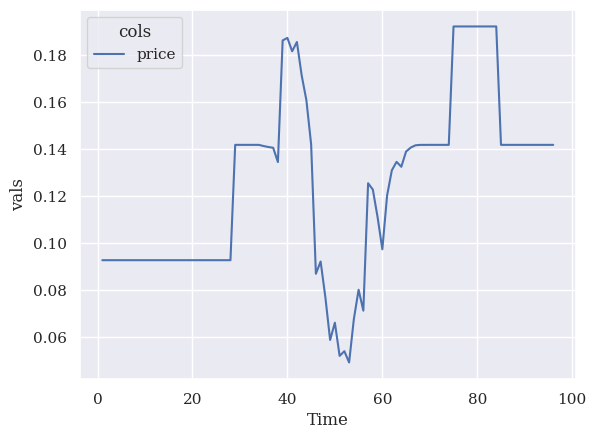

In [8]:
df = out[["Time","price","sum_energy","sum_money","total_demand"]].copy()
df["energy_money_ratio"]= df["sum_energy"]/df["sum_money"]
df = df.melt("Time",value_vars=["price"],var_name="cols",value_name="vals")
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
sns.lineplot(df,x="Time",y="vals",hue="cols",estimator="mean")
#sns.lineplot(df,x="Time",y="vals",hue="cols",estimator="mean")

<Axes: xlabel='Time', ylabel='sum_energy'>

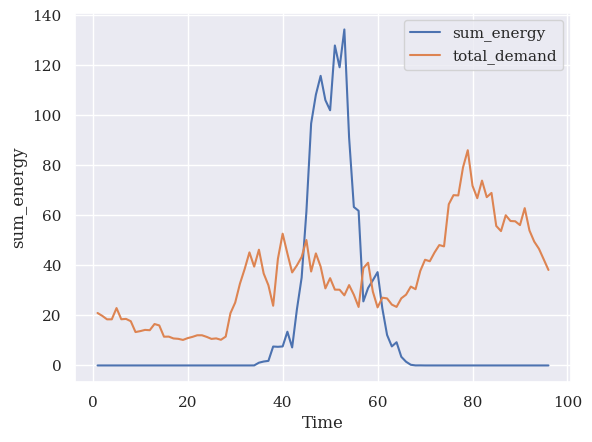

In [17]:
sns.lineplot(out,x="Time",y="sum_energy",label="sum_energy")
sns.lineplot(out,x="Time",y="sum_money",label="total_demand")

In [26]:
data = pd.read_excel("./data/input_data_70_pv.xlsx")
data.set_index(["Time","ID"],inplace=True)
data["deposited_money"]=data["demand"]*data["bid_price_buyers"]

# define price function
def price_function(ratio, K_upper, K_lower, theta, B):
    return K_upper - (K_upper - K_lower) / (1 + np.exp(-B * (ratio - theta)))

    
def optimize_func(params,data,alpha):
    midpoint,steepness =params 
    print(params)
    mean_differences = []
    for i in data.index.get_level_values(0).unique():
        utilities=[]
        profits=[]
        slice = data.xs(i)
        k_lower= slice["sell_price"].mean()
        k_upper = slice["buy_price"].mean()
        sum_energy = slice["surplus"].sum()
        sum_money = slice["deposited_money"].sum()
        total_demand = slice["demand"].sum()
        ratio = sum_energy/sum_money
        price = price_function(ratio,k_upper,k_lower,midpoint,steepness)
        total_affordable_energy= sum_money/price
        sum_sold_energy = min(total_affordable_energy,sum_energy)
        for j,row in slice.iterrows():
            if row.demand > 0:
                received_energy = sum_sold_energy * (row["deposited_money"]/sum_money)                     
                excess_received_energy = max(received_energy - row["demand"],0)               
                utility_per_energy = k_upper-price               
                cost_per_excess_energy = price-k_lower              
                utility = utility_per_energy*(received_energy-excess_received_energy) - excess_received_energy*cost_per_excess_energy
                utility_per_energy = None if received_energy == 0 else utility/received_energy
                utilities.append(utility_per_energy)
            else:
                sold_energy = sum_sold_energy*(row.surplus/sum_energy)               
                profit_per_energy = None if sold_energy== 0 else price - k_lower
                profit = sold_energy*profit_per_energy
                profits.append(profit_per_energy)
        mean_utility = 0 if len(list(filter(None,utilities))) == 0 else sum(list(filter(None,utilities)))/len(list(filter(None,utilities)))
        mean_profit = 0 if len(list(filter(None,profits))) == 0 else sum(list(filter(None,profits)))/len(list(filter(None,profits)))
        min_return = min(mean_utility,mean_profit)
        mean_differences.append(min_return)

    agg = data.groupby("Time").agg({"surplus":"sum","deposited_money":"sum"})
    s_d_ratios = agg["surplus"]/agg["deposited_money"]

    K_upper_val = data[data["surplus"]>0]["buy_price"].mean()
    K_lower_val = data[data["surplus"]>0]["sell_price"].mean()

    # remove 0 ratios, as we only care about available surplus times
    s_d_ratios = [i for i in s_d_ratios if i > 0]
    max_sd = max(s_d_ratios)
    min_sd = min(s_d_ratios)
    mean_sd =np.mean(s_d_ratios)

    # The price when demand is exactly at the lowest supply to demand ratio transition 
    price_at_lower_transition = price_function(0,K_upper_val, K_lower_val, midpoint, steepness)
    
    # The price when demand is exactly at the mean supply to demand ratio transition 
    price_at_middle_transition = price_function(mean_sd,K_upper_val, K_lower_val, midpoint, steepness)

    # The price when demand is exactly at the upper supply to demand ratio transition 
    price_at_upper_transition = price_function(max_sd, K_upper_val, K_lower_val, midpoint, steepness)
    
    # Ensure the price at the lower transition is close to K_lower and at the upper transition is close to K_upper
    term1 = abs(price_at_lower_transition - K_upper_val)
    term2 = abs(price_at_upper_transition - K_lower_val)
    term3 = abs(price_at_middle_transition- ((K_upper_val+K_lower_val)/2))

    return -np.mean(mean_differences) + (term1+term2+term3)*alpha

optimize_func((1,1),data,0.5)

(1, 1)


np.float64(0.031867727882265565)

In [30]:
######### OPTIMIZATION for different alphas and scenarios ##################

######### Read in Scenarios ############
data1 = pd.read_excel("./data/input_data_30_pv.xlsx")
data1.set_index(["Time","ID"],inplace=True)
data1["deposited_money"]=data1["demand"]*data1["bid_price_buyers"]
data2 = pd.read_excel("./data/input_data_50_pv.xlsx")
data2.set_index(["Time","ID"],inplace=True)
data2["deposited_money"]=data2["demand"]*data2["bid_price_buyers"]
data3 = pd.read_excel("./data/input_data_70_pv.xlsx")
data3.set_index(["Time","ID"],inplace=True)
data3["deposited_money"]=data3["demand"]*data3["bid_price_buyers"]

alphas = [0.5,0.4,0.3]
initial_guess = [1, 1]
bnds = [(0, 50), (0, 50)]
optimal_params = {}

for i in alphas:
    #### Optimization 3
    result_optimizier_3 = minimize(optimize_func,bounds=bnds,args=(data3,i),x0=[1,1])
    optimal_params["alpha = "+str(i) +" scenario_high:"] =  {"midpoint":result_optimizier_3.x[0],"steepness":result_optimizier_3.x[1]}
    #### Optimization 2
    result_optimizier_2 = minimize(optimize_func,bounds=bnds,args=(data2,i),x0=[1,1])
    optimal_params["alpha = "+str(i) +" scenario_mid:"] =  {"midpoint":result_optimizier_2.x[0],"steepness":result_optimizier_2.x[1]}
    #### Optimization 1
    result_optimizier_1 = minimize(optimize_func,bounds=bnds,args=(data1,i),x0=[1,1])
    optimal_params["alpha = "+str(i) +" scenario_low:"] =  {"midpoint":result_optimizier_1.x[0],"steepness":result_optimizier_1.x[1]}

[1. 1.]
[1.00000001 1.        ]
[1.         1.00000001]
[1.00628419 0.99746036]
[1.0062842  0.99746036]
[1.00628419 0.99746037]
[1.01258003 0.99484542]
[1.01258004 0.99484542]
[1.01258003 0.99484543]
[1.03776341 0.98438569]
[1.03776342 0.98438569]
[1.03776341 0.9843857 ]
[1.13849695 0.94254673]
[1.13849696 0.94254673]
[1.13849695 0.94254674]
[1.54143108 0.77519091]
[1.54143109 0.77519091]
[1.54143108 0.77519092]
[3.15316761 0.10576764]
[3.15316762 0.10576764]
[3.15316761 0.10576765]
[2.46162261 0.39299593]
[2.46162262 0.39299593]
[2.46162261 0.39299594]
[3.10440848 0.1260194 ]
[3.10440849 0.1260194 ]
[3.10440848 0.12601941]
[3.15316761 0.10576764]
[3.15316762 0.10576764]
[3.15316761 0.10576765]
[2.80757926 0.71664972]
[2.80757927 0.71664972]
[2.80757926 0.71664973]
[3.12052877 0.16346196]
[3.12052878 0.16346196]
[3.12052877 0.16346197]
[3.14567309 0.11901539]
[3.1456731  0.11901539]
[3.14567309 0.1190154 ]
[3.36476767 0.12180943]
[3.36476768 0.12180943]
[3.36476767 0.12180944]
[4.24114

In [31]:
optimal_params

{'alpha = 0.5 scenario_high:': {'midpoint': np.float64(5.953998393410741),
  'steepness': np.float64(0.19187317821232616)},
 'alpha = 0.5 scenario_mid:': {'midpoint': np.float64(2.7366558386807447),
  'steepness': np.float64(0.4127245127514755)},
 'alpha = 0.5 scenario_low:': {'midpoint': np.float64(1.252280038881754),
  'steepness': np.float64(0.9025061693804254)},
 'alpha = 0.4 scenario_high:': {'midpoint': np.float64(5.953993075021397),
  'steepness': np.float64(0.15053086175567595)},
 'alpha = 0.4 scenario_mid:': {'midpoint': np.float64(2.7366560790505705),
  'steepness': np.float64(0.3065393825508552)},
 'alpha = 0.4 scenario_low:': {'midpoint': np.float64(1.252280042111915),
  'steepness': np.float64(0.7551588454381338)},
 'alpha = 0.3 scenario_high:': {'midpoint': np.float64(1.0488555089912404),
  'steepness': np.float64(0.07468636012301118)},
 'alpha = 0.3 scenario_mid:': {'midpoint': np.float64(2.7366473252185495),
  'steepness': np.float64(0.17867019571211798)},
 'alpha = 0.3

In [264]:
print(result_optimizier_1.x)
print(result_optimizier_2.x)
print(result_optimizier_3.x)


[1.2548508  0.76542426]
[2.73324605 0.34748057]
[5.96011095 0.16340297]


In [ ]:
def optimize_func(params,data,alpha):
    
    agg = data.groupby("Time").agg({"surplus":"sum","deposited_money":"sum",'demand':})
    s_d_ratios = agg["surplus"]/agg["deposited_money"]

    K_upper_val = data[data["surplus"]>0]["buy_price"].mean()
    K_lower_val = data[data["surplus"]>0]["sell_price"].mean()

    # remove 0 ratios, as we only care about available surplus times
    s_d_ratios = [i for i in s_d_ratios if i > 0]
    max_sd = max(s_d_ratios)
    min_sd = min(s_d_ratios)
    mean_sd =np.mean(s_d_ratios)

    # The price when demand is exactly at the lowest supply to demand ratio transition 
    price_at_lower_transition = price_function(0,K_upper_val, K_lower_val, midpoint, steepness)
    
    # The price when demand is exactly at the mean supply to demand ratio transition 
    price_at_middle_transition = price_function(mean_sd,K_upper_val, K_lower_val, midpoint, steepness)

    # The price when demand is exactly at the upper supply to demand ratio transition 
    price_at_upper_transition = price_function(max_sd, K_upper_val, K_lower_val, midpoint, steepness)
    
    # Ensure the price at the lower transition is close to K_lower and at the upper transition is close to K_upper
    term1 = abs(price_at_lower_transition - K_upper_val)
    term2 = abs(price_at_upper_transition - K_lower_val)
    term3 = abs(price_at_middle_transition- ((K_upper_val+K_lower_val)/2))

    return -np.mean(mean_differences) + (term1+term2+term3)/6